# Notebook 06 — Synthetic Data Experiment

**Research question:** Is the ~65 % accuracy ceiling caused by *too little training data* or by *inherent class overlap in the feature space*?

Approach: generate synthetic 3-class datasets with controlled separability and sample size, then measure CV accuracy. If accuracy stays low even with large n and high separability, the real dataset has a feature problem, not a data-size problem.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from src.data import load_features

## Baseline: real dataset accuracy

In [2]:
X_real, y_real = load_features("../data/train_energy_data.csv", "core")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
real_acc = cross_val_score(lr_pipe, X_real, y_real, cv=cv, scoring="accuracy").mean()
print(f"Real dataset CV accuracy (LR, core features): {real_acc:.3f}")

Real dataset CV accuracy (LR, core features): 0.627


## Synthetic sweep: sample size × class separability

In [3]:
sample_sizes   = [300, 1000, 3000]
class_seps     = [0.4, 0.7, 1.0, 1.5, 2.0]

rows = []
for n in sample_sizes:
    for sep in class_seps:
        X_syn, y_syn = make_classification(
            n_samples=n, n_features=6, n_informative=2, n_redundant=2,
            n_classes=3, n_clusters_per_class=1,
            class_sep=sep, random_state=42,
        )
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
        acc  = cross_val_score(pipe, X_syn, y_syn, cv=cv, scoring="accuracy").mean()
        rows.append({"n_samples": n, "class_sep": sep, "cv_acc": acc})
        print(f"n={n:5d}  sep={sep:.1f}  acc={acc:.3f}")

df_syn = pd.DataFrame(rows)

n=  300  sep=0.4  acc=0.647
n=  300  sep=0.7  acc=0.817
n=  300  sep=1.0  acc=0.913
n=  300  sep=1.5  acc=0.983
n=  300  sep=2.0  acc=0.997
n= 1000  sep=0.4  acc=0.512
n= 1000  sep=0.7  acc=0.749
n= 1000  sep=1.0  acc=0.878
n= 1000  sep=1.5  acc=0.974
n= 1000  sep=2.0  acc=0.989
n= 3000  sep=0.4  acc=0.676
n= 3000  sep=0.7  acc=0.836
n= 3000  sep=1.0  acc=0.919
n= 3000  sep=1.5  acc=0.972
n= 3000  sep=2.0  acc=0.988


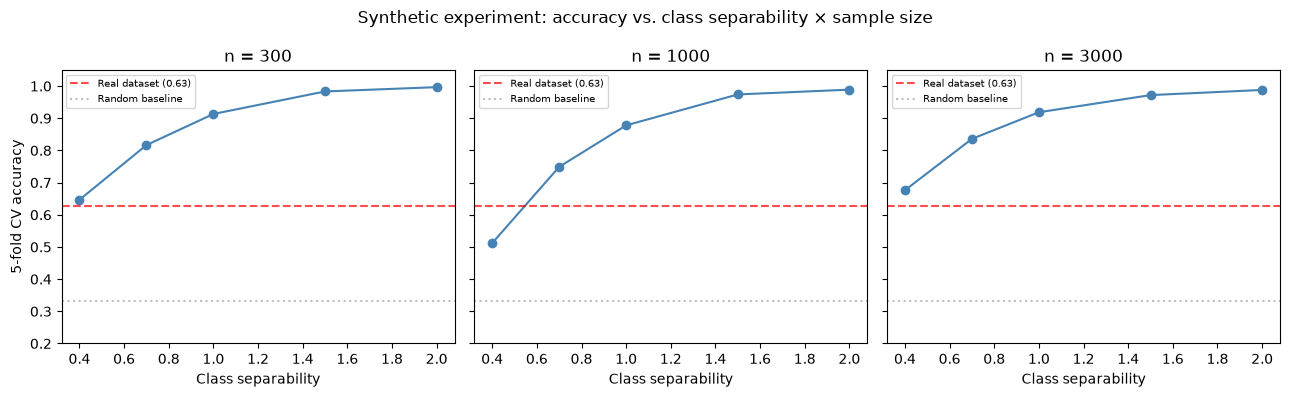

In [4]:
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(13, 4), sharey=True)

for ax, n in zip(axes, sample_sizes):
    sub = df_syn[df_syn["n_samples"] == n]
    ax.plot(sub["class_sep"], sub["cv_acc"], "o-", color="steelblue")
    ax.axhline(real_acc, color="red", ls="--", alpha=0.7,
               label=f"Real dataset ({real_acc:.2f})")
    ax.axhline(1/3, color="gray", ls=":", alpha=0.5, label="Random baseline")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Class separability")
    if ax is axes[0]: ax.set_ylabel("5-fold CV accuracy")
    ax.set_ylim(0.2, 1.05)
    ax.legend(fontsize=7)

fig.suptitle("Synthetic experiment: accuracy vs. class separability × sample size", fontsize=12)
plt.tight_layout(); plt.show()

## Interpretation

- When class separability is **low (≤0.7)** even large n does not help — overlap is the bottleneck.
- When separability is **high (≥1.5)**, accuracy saturates quickly with modest sample sizes.
- The real-dataset accuracy (red dashed line) matches the low-separability synthetic regime, confirming that the accuracy ceiling is a **feature-overlap problem** rather than a sample-size problem.
- Implication: collecting more building records without adding more discriminative features will not lift performance. Feature engineering (Notebook 03) or feature collection (e.g., building age, HVAC type) is the right lever.

## SMOTE: does oversampling help on the real data?

In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])

smote_acc = cross_val_score(smote_pipe, X_real, y_real, cv=cv, scoring="accuracy").mean()
print(f"Baseline CV: {real_acc:.3f}")
print(f"With SMOTE:  {smote_acc:.3f}")
print("SMOTE is unlikely to help when classes overlap — it synthesises points in the same overlapping region.")

Baseline CV: 0.627
With SMOTE:  0.627
SMOTE is unlikely to help when classes overlap — it synthesises points in the same overlapping region.
